In [87]:
%matplotlib notebook

In [1]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [2]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

In [7]:
hejret_train

,gene,noncodingRNA,noncodingRNA_name,noncodingRNA_fam,feature,label,chr,start,end,strand,gene_cluster_ID
0,CCCAGGGTGTTTCATGCTGAGGTAGTAGGATGAATAAAGGCAAATA...,CTATACAATCTACTGTCTTTC,hsa-let-7a-3p,let-7,NaN,1,13,103634174,103634223,-,355
1,CAACTCTATACAACACACCTACTATCTCTTGATGCCCTATTGACAG...,TGAGGTAGTAGGTTGTGTGGTT,hsa-let-7a-5p,let-7,exon,1,10,102362496,102362545,+,1611
2,TAGAGGATCCTAGACCAGCATGCCAGTGTGCCAAGGCCACAGGGAA...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,65500706,65500755,+,1457
3,CATCCCCCTGACGGCCGAGAAGCTGTGCATCTACACCGACAACTCC...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,69643180,69643229,+,97
4,CAACATGAAACAGTTCATCCGCTACCTCATCTCGTCCAACGTCGGG...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,12,110342392,110342441,+,3303
...,...,...,...,...,...,...,...,...,...,...,...
8188,TGATAGTTCAGCTTGAATGTCTCTTAGAGGGTGGGCTTTTGTTGAT...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,exon,0,11,65502560,65502609,+,2508
8189,GTGGGACTGCTCTGTCCCCTGCCCCTACTGCAGAGATAGCACTGCC...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,three_prime_utr,0,17,49053543,49053592,+,239
8190,CCATTTCTTTGGATTTGCCTCTCCTGGACATTTCATATAGATGAAA...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,intron,0,15,101365823,101365872,-,423
8191,CATCACATGCAGGTGGGCCTGGGCTCCTTGGGAGGAAGTATGGTGG...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,"intron,exon",0,17,1651376,1651425,-,65


# Optimization

### Simple model on miRNA alignments:

In [8]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [9]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [10]:
mirlist[0]

Seq('CTATACAATCTACTGTCTTTC')

In [11]:
genelist[0]

Seq('TGCATATTTGCCTTTATTCATCCTACTACCTCAGCATGAAACACCCTGGG')

In [12]:
print(next(aligner.align(mirlist[1], genelist[1])))

target            1 GAGGTAGTAGGT-TG-TGT---G-GTT 22
                  0 |||.||||||||-||-|||---|-||| 27
query            22 GAGATAGTAGGTGTGTTGTATAGAGTT 49



In [13]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

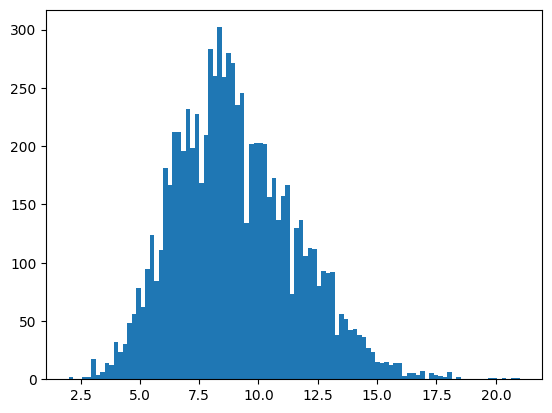

In [14]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [15]:
true_alpha = -9

In [16]:
logit_scores = logit_partial_scores(scores, true_alpha)

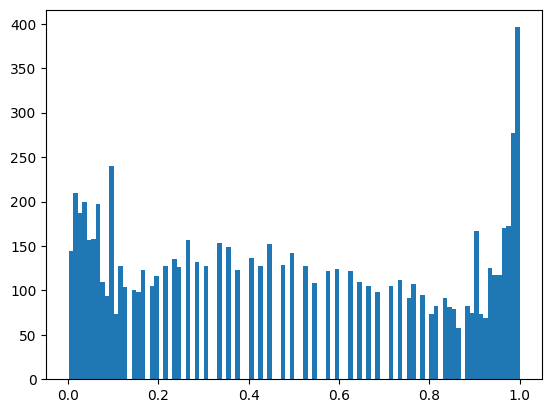

In [17]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [19]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False, False,  True])

In [20]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -10002.78024009512
True LogL: -3189.780240095122


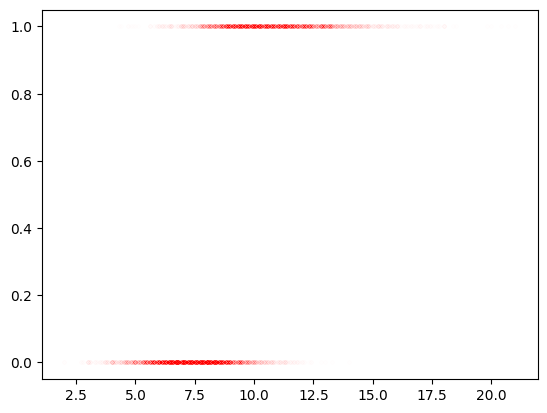

In [21]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

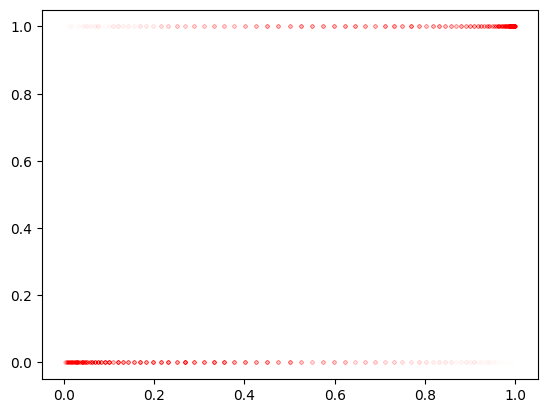

In [22]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [36]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [37]:
NITER = 50

In [42]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)

Alphabet:
TCGA
Initial parameters:
{'alpha': -8.710709325380378, 'match_score': 0.9836386929743514, 'mismatch_score': -0.8373399075030562, 'open_gap_score': -1.236986974936751, 'extend_gap_score': -0.10181431306265006}
Start of iteration 0
Current alpha: -8.710709325380378
Current logL: -3230.6819791957414
Updated alpha: -8.877743691483026
Updated logL: -3215.6791794892565
New subgradient:
{'Substitutions': Array([[ 33.60093187, -23.08992666,   0.49500578,  -0.15186756],
       [-11.75287578, 125.91357503, -32.67106182, -38.37790045],
       [-21.17350654, -18.25275999,  93.69380009, -23.36264143],
       [-11.40704498, -21.96463974, -10.17173535,  15.15363689]],
         alphabet='TCGA'), 'Gap opens': 224.51317590067984, 'Gap extends': 485.455171606454}
Stepsize: 1e-05
Gap open step: 0.0022451317590067984
Gap extend step: 0.0048545517160645405
Match step: 0.0026836194387497877
Mismatch step: -0.0021188095451299188
New parameters:
{'alpha': -8.877743691483026, 'match_score': 0.98637934

Current alpha: -9.189270025328113
Current logL: -3203.647518480857
Updated alpha: -9.20520276133002
Updated logL: -3203.5122190168313
New subgradient:
{'Substitutions': Array([[-28.99474976, -17.44859739,   1.97612602,   3.34074945],
       [-12.991099  ,  75.75107614, -28.05430934, -34.30170758],
       [-21.25599948, -17.82811723,  49.47141637, -19.59933156],
       [ -5.72801362, -20.87163143,  -7.96052981, -14.6471241 ]],
         alphabet='TCGA'), 'Gap opens': 108.68301073195528, 'Gap extends': -40.85061226159436}
Stepsize: 1e-05
Gap open step: 0.0010868301073195528
Gap extend step: -0.0004085061226159436
Match step: 0.0008158061864814946
Mismatch step: -0.0018072246097457596
New parameters:
{'alpha': -9.20520276133002, 'match_score': 0.9985892378446114, 'mismatch_score': -0.8573275129850204, 'open_gap_score': -1.2213925976068678, 'extend_gap_score': -0.09060179283253711}
Subgradient norm: 229.77548734282198
End of iteration 9

Start of iteration 10
Current alpha: -9.2052027613300

Current alpha: -9.2820376228295
Current logL: -3199.336723848428
Updated alpha: -9.29082101006051
Updated logL: -3199.295807309977
New subgradient:
{'Substitutions': Array([[-39.53863893, -19.17438572,   4.63146742,   6.50297917],
       [-11.70449778,  71.52788106, -27.63115104, -31.96701744],
       [-19.4951962 , -14.78927548,  37.11820083, -17.92453796],
       [ -4.48878098, -21.75184467,  -7.66787198, -22.82355074]],
         alphabet='TCGA'), 'Gap opens': 83.46069554425262, 'Gap extends': -66.6011829541191}
Stepsize: 1e-05
Gap open step: 0.0008346069554425262
Gap extend step: -0.000666011829541191
Match step: 0.00046283892216634516
Mismatch step: -0.0016546011265717157
New parameters:
{'alpha': -9.29082101006051, 'match_score': 1.0046372056668211, 'mismatch_score': -0.8730606551912982, 'open_gap_score': -1.2127193618652428, 'extend_gap_score': -0.09322341149272446}
Subgradient norm: 202.2885385553601
End of iteration 18

Start of iteration 19
Current alpha: -9.29082101006051
Cur

Current alpha: -9.329527175945755
Current logL: -3196.221670188814
Updated alpha: -9.332999527291749
Updated logL: -3196.2152964500087
New subgradient:
{'Substitutions': Array([[-51.98023427, -16.45609395,   5.19414581,   9.0056644 ],
       [ -9.56480898,  67.76018779, -26.28361695, -30.74408352],
       [-20.42731597, -14.78356517,  46.2499975 , -17.40577697],
       [ -4.56647711, -19.35250405,  -6.5579968 , -28.64529811]],
         alphabet='TCGA'), 'Gap opens': 66.82861257452136, 'Gap extends': -21.01038580565783}
Stepsize: 1e-05
Gap open step: 0.0006682861257452136
Gap extend step: -0.00021010385805657832
Match step: 0.00033384652910596206
Mismatch step: -0.0015194242926016353
New parameters:
{'alpha': -9.332999527291749, 'match_score': 1.0082168339542894, 'mismatch_score': -0.8874413147507004, 'open_gap_score': -1.2059626044722718, 'extend_gap_score': -0.09503678206662804}
Subgradient norm: 170.61224056256586
End of iteration 27

Start of iteration 28
Current alpha: -9.332999527

Current alpha: -9.358535347369427
Current logL: -3193.9657722459942
Updated alpha: -9.360602626720954
Updated logL: -3193.9635179174265
New subgradient:
{'Substitutions': Array([[-56.32000783, -17.04881421,   5.63917073,  12.05545554],
       [ -7.79077204,  60.9952378 , -24.94163465, -28.408426  ],
       [-21.00871995, -12.1868789 ,  38.85943651, -15.65316832],
       [ -5.36581656, -17.49548625,  -6.6058577 , -33.27647959]],
         alphabet='TCGA'), 'Gap opens': 41.22529825147408, 'Gap extends': 4.757819934644036}
Stepsize: 1e-05
Gap open step: 0.00041225298251474084
Gap extend step: 4.757819934644037e-05
Match step: 0.00010258186892614767
Mismatch step: -0.001388109483093969
New parameters:
{'alpha': -9.360602626720954, 'match_score': 1.0104997330110685, 'mismatch_score': -0.9002655607859051, 'open_gap_score': -1.2009822112977608, 'extend_gap_score': -0.09588235568657938}
Subgradient norm: 145.2441800394472
End of iteration 36

Start of iteration 37
Current alpha: -9.360602626720

Current alpha: -9.359535914964118
Current logL: -3192.2164053841275
Updated alpha: -9.3638240041739
Updated logL: -3192.206715156337
New subgradient:
{'Substitutions': Array([[-55.81769265, -16.09241842,   7.26799854,  12.51397209],
       [ -7.93222662,  57.05145682, -22.6411391 , -28.28531842],
       [-17.70838689,  -9.03404404,  37.47248774, -13.09959081],
       [ -4.26742883, -15.33093694,  -6.78994418, -36.74294954]],
         alphabet='TCGA'), 'Gap opens': 28.40731265392072, 'Gap extends': -50.60650024478627}
Stepsize: 1e-05
Gap open step: 0.0002840731265392072
Gap extend step: -0.0005060650024478628
Match step: 1.9633023629293763e-05
Mismatch step: -0.0012139946362564951
New parameters:
{'alpha': -9.3638240041739, 'match_score': 1.0112714378025889, 'mismatch_score': -0.912152542144634, 'open_gap_score': -1.1976433657649674, 'extend_gap_score': -0.09694009984931272}
Subgradient norm: 134.57220219646715
End of iteration 45

Start of iteration 46
Current alpha: -9.3638240041739
C

In [43]:
print(params['final_loglik'])

-3191.4601452854713


In [44]:
print(params['final_loglik'])

-3191.4601452854713


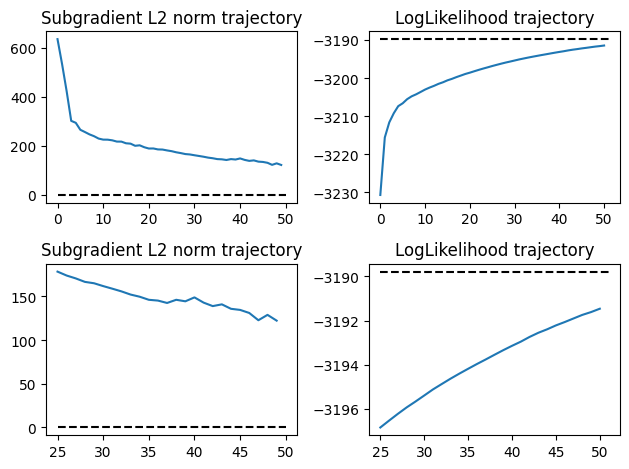

In [45]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

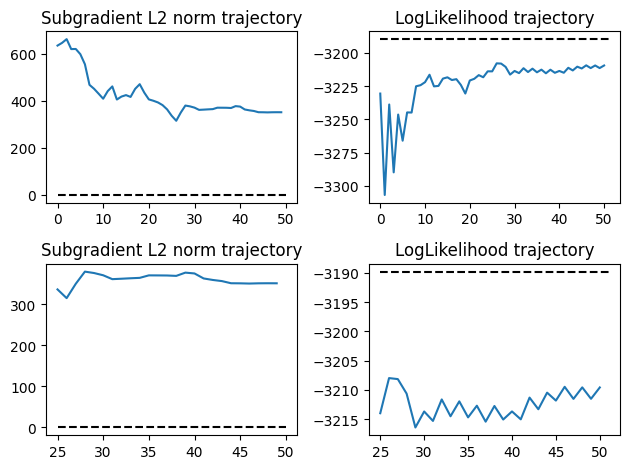

In [29]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [68]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 [0.99043018]
-1 [-0.96008404]
-1.2 [-1.15123837]
-0.1 [-0.10372796]
-9 -9.008323871219716


### Step function parameters experiment

In [71]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [80]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [72]:
steplengts = np.linspace(0.000005, 0.00005, num=10)
steplengts

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [83]:
NITER = 10

In [84]:
estimalign_results = []
for stepl in steplengts:
    const_step = create_constant_step(stepl)
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results.append(params)


<IPython.core.display.Javascript object>


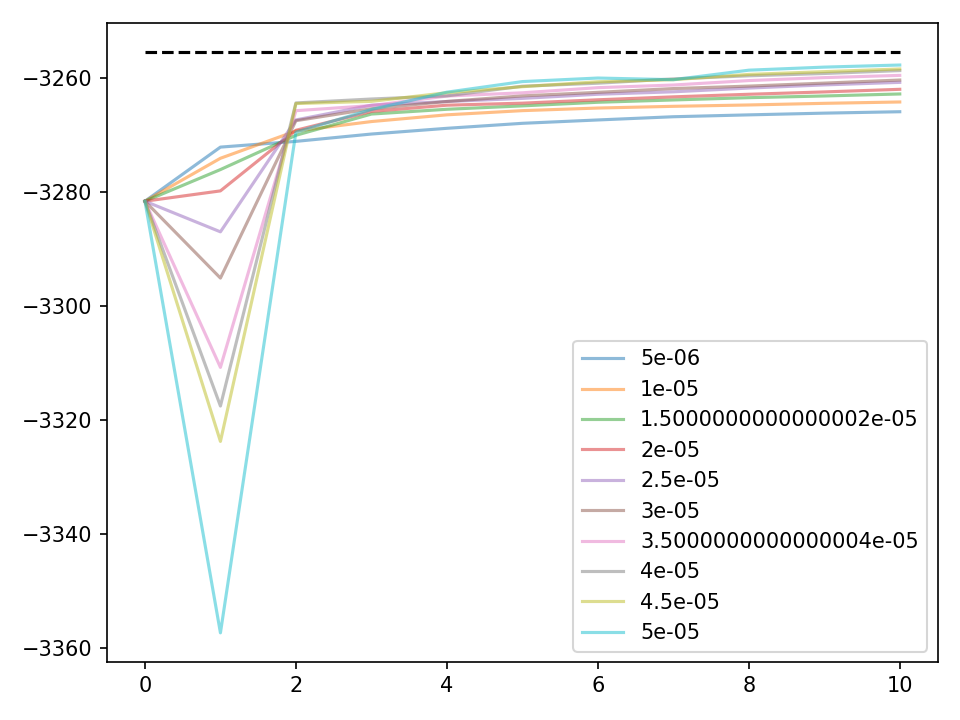

In [91]:
plt.figure()
for params in estimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend(steplengts)
plt.tight_layout()
# plt.savefig('path', dpi=160)

<IPython.core.display.Javascript object>


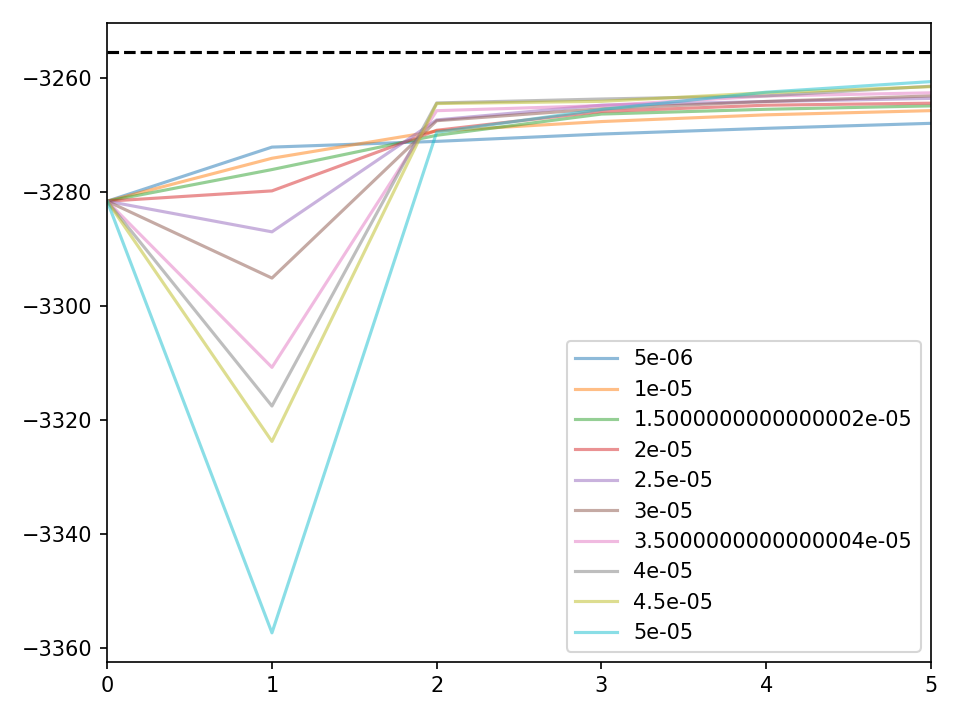

In [90]:
plt.figure()
for params in estimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend(steplengts)
plt.xlim(0, 5)
plt.tight_layout()

### Replicates

In [64]:
REPS = 20
NITER = 5

In [65]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [66]:
estimalign_results = []
true_logLs = []
for _ in range(REPS):
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    true_logLs.append(true_logL)
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results.append(params)


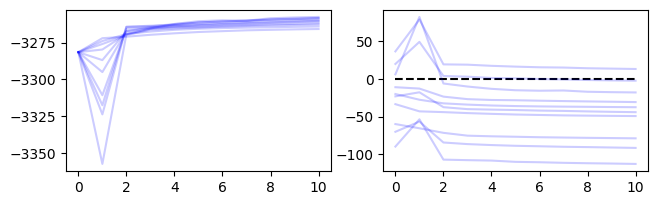

In [85]:
plt.figure(figsize=(7.5, 2.1))
plt.subplot(121)
for params in estimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.2, color='b')
plt.subplot(122)
plt.plot([0, NITER], [0, 0], 'k--')
for params, tlL in zip(estimalign_results, true_logLs):
    plt.plot(np.arange(NITER+1), tlL - params['loglik_trajectory'], alpha=0.2, color='b')

### General matrix, affine gap penalty

In [14]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [15]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [16]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

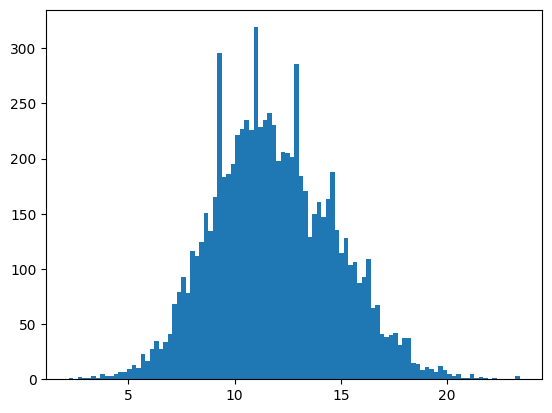

In [17]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [18]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

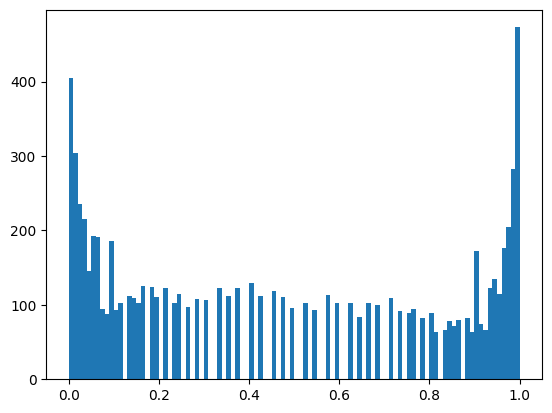

In [19]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [20]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -2915.9308504149258


In [21]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [22]:
NITER = 200

In [23]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
TAGC
Initial parameters:
{'alpha': -9.646821800363519, 'substitution_matrix': Array([[ 0.85129634, -0.91654066, -0.79529273, -0.52122748],
       [-0.76003858,  0.85142959, -0.55241136, -0.312354  ],
       [-0.733926  , -0.37365855,  1.14089295, -0.81600721],
       [-0.41901523, -0.59584093, -0.7260091 ,  1.06109003]],
         alphabet='TAGC'), 'open_gap_score': -1.1884549597794114, 'extend_gap_score': -0.0773289404440564}
Start of iteration 0
Current alpha: -9.646821800363519
Current logL: -3032.30679788916
Updated alpha: -9.975817300062882
Updated logL: -2976.041520988888
New subgradient:
{'Substitutions': Array([[ 9.84213929e+01, -1.54101927e+01,  5.92027744e+00,
         4.12996227e+01],
       [-1.79189825e+01,  1.49501546e+02, -3.19720467e+01,
        -1.57193289e-01],
       [-2.37134799e+01, -1.26814283e-01,  1.30403240e+02,
        -2.93871200e+01],
       [ 3.92570401e+01, -4.75574812e-01, -1.95832028e+01,
         1.21849394e+02]],
         alphabet='TAGC'), 'Ga

Current alpha: -10.554829672970536
Current logL: -2961.8801163448284
Updated alpha: -10.681724536374224
Updated logL: -2953.6501600583574
New subgradient:
{'Substitutions': Array([[ 66.63751777, -13.93202934,   7.76411601,  42.59127903],
       [-14.55836496,  68.5298311 , -27.0849432 ,   5.7976759 ],
       [-19.08265217,   1.60134187,  75.19687075, -26.00545537],
       [ 32.14851963,  -0.57637111,  -9.56267469,  77.69841424]],
         alphabet='TAGC'), 'Gap opens': 87.69841471829892, 'Gap extends': -53.8681093563608}
Stepsize: 5e-05
Gap open step: 0.004384920735914947
Gap extend step: -0.00269340546781804
New parameters:
{'alpha': -10.681724536374224, 'substitution_matrix': Array([[ 0.88044869, -0.92214372, -0.79179554, -0.50413763],
       [-0.76645879,  0.89050863, -0.56352132, -0.31072633],
       [-0.74261556, -0.37307205,  1.18173674, -0.82674894],
       [-0.40485879, -0.59674458, -0.73133898,  1.09923473]],
         alphabet='TAGC'), 'open_gap_score': array([-1.14292941]), '

Current alpha: -11.027887276191047
Current logL: -2945.331660275737
Updated alpha: -11.071299130411527
Updated logL: -2944.382865216668
New subgradient:
{'Substitutions': Array([[ 37.87667352, -19.27137688,  15.46591474,  37.58949886],
       [-15.45347032,  48.81338026, -28.38112844,   6.08155381],
       [-18.41544492,  -1.60173049,  46.62351516, -25.23341969],
       [ 27.90625193,  -2.95191021,  -9.99279275,  48.36540302]],
         alphabet='TAGC'), 'Gap opens': 26.573106876899182, 'Gap extends': 25.642810756901646}
Stepsize: 5e-05
Gap open step: 0.0013286553438449592
Gap extend step: 0.0012821405378450825
New parameters:
{'alpha': -11.071299130411527, 'substitution_matrix': Array([[ 0.89991721, -0.92909965, -0.7866638 , -0.48865968],
       [-0.77204787,  0.91331017, -0.57501242, -0.3080388 ],
       [-0.75061223, -0.37198568,  1.20627566, -0.83703119],
       [-0.39291181, -0.5976423 , -0.7353582 ,  1.12198928]],
         alphabet='TAGC'), 'open_gap_score': array([-1.11940529]),

Current alpha: -11.281086549018191
Current logL: -2940.642716891542
Updated alpha: -11.26888618201616
Updated logL: -2940.568443413954
New subgradient:
{'Substitutions': Array([[ 29.12814803, -22.19201796,  14.12586325,  33.13692106],
       [-14.75990551,  35.51532364, -26.91004401,   5.03598995],
       [-17.24147034,   0.3027799 ,  34.20177204, -27.08100179],
       [ 23.29411717,  -2.47218173, -10.65788445,  34.11128757]],
         alphabet='TAGC'), 'Gap opens': 5.168573749401325, 'Gap extends': 58.59968264792603}
Stepsize: 5e-05
Gap open step: 0.0002584286874700663
Gap extend step: 0.002929984132396302
New parameters:
{'alpha': -11.26888618201616, 'substitution_matrix': Array([[ 0.91283872, -0.93709659, -0.78084867, -0.47500719],
       [-0.77796769,  0.92873   , -0.58582662, -0.30540048],
       [-0.75705523, -0.37206371,  1.2199759 , -0.84710366],
       [-0.38262556, -0.5989119 , -0.73982184,  1.13539025]],
         alphabet='TAGC'), 'open_gap_score': array([-1.12311748]), 'ext

Current alpha: -11.460986192820322
Current logL: -2939.100480698773
Updated alpha: -11.411178257494669
Updated logL: -2937.871523327749
New subgradient:
{'Substitutions': Array([[ 28.95119408, -21.93061342,  13.9094487 ,  26.57028174],
       [-15.16649484,  26.5011993 , -27.06858915,   6.6343769 ],
       [-17.21539573,  -0.24661682,  32.34139762, -26.52962318],
       [ 19.77834705,  -4.31353549, -11.02591155,  29.17071458]],
         alphabet='TAGC'), 'Gap opens': 5.063751742867396, 'Gap extends': 144.2930340293609}
Stepsize: 5e-05
Gap open step: 0.0002531875871433698
Gap extend step: 0.007214651701468046
New parameters:
{'alpha': -11.411178257494669, 'substitution_matrix': Array([[ 0.92282616, -0.94545996, -0.77562858, -0.463346  ],
       [-0.7836831 ,  0.94011279, -0.5964814 , -0.3026782 ],
       [-0.76335127, -0.37246839,  1.23153053, -0.85736335],
       [-0.37340061, -0.60006438, -0.74421554,  1.14592549]],
         alphabet='TAGC'), 'open_gap_score': array([-1.12643403]), 'e

...

New subgradient:
{'Substitutions': Array([[  3.85370438, -13.52300555,  -4.27149777,   1.16303153],
       [-10.88355568,   3.87275612,  -6.03697693,  -0.18894178],
       [ -7.11046587,  -1.04468717,   8.93424942, -18.92446514],
       [  3.4804777 ,  -0.65460018,  -7.38666471,   6.47992856]],
         alphabet='TAGC'), 'Gap opens': 2.492967884041308, 'Gap extends': 37.22256068254271}
Stepsize: 5e-05
Gap open step: 0.0001246483942020654
Gap extend step: 0.0018611280341271357
New parameters:
{'alpha': -12.188410694059327, 'substitution_matrix': Array([[ 0.98793206, -1.06754777, -0.73561895, -0.40669669],
       [-0.88152883,  1.00143419, -0.69846989, -0.284695  ],
       [-0.83432498, -0.38905565,  1.30125385, -1.00165397],
       [-0.28101133, -0.60041814, -0.81297146,  1.20756258]],
         alphabet='TAGC'), 'open_gap_score': array([-1.19186191]), 'extend_gap_score': array([-0.09160552])}
Subgradient norm: 48.76153305016459
End of iteration 166

Start of iteration 167
Current alpha:

Current alpha: -12.209937485939914
Current logL: -2920.3898441598712
Updated alpha: -12.2099821863138
Updated logL: -2920.3898432065325
New subgradient:
{'Substitutions': Array([[  3.47755481, -12.68443718,  -4.13733756,   1.47565863],
       [-10.44524235,   2.86548009,  -5.89792061,   0.18441759],
       [ -7.31412028,  -0.41202843,   4.99700408, -20.19955765],
       [  3.1818554 ,  -0.78819621,  -6.93514453,   4.19046438]],
         alphabet='TAGC'), 'Gap opens': -2.045255970013674, 'Gap extends': 13.88834890521916}
Stepsize: 5e-05
Gap open step: -0.0001022627985006837
Gap extend step: 0.0006944174452609581
New parameters:
{'alpha': -12.2099821863138, 'substitution_matrix': Array([[ 0.98931351, -1.07272367, -0.73602241, -0.4061297 ],
       [-0.88580904,  1.0023412 , -0.70092392, -0.28473146],
       [-0.83753405, -0.38927694,  1.30307226, -1.00978831],
       [-0.27948749, -0.60062039, -0.81578154,  1.20901035]],
         alphabet='TAGC'), 'open_gap_score': array([-1.19365593]), '

Current alpha: -12.236251688732944
Current logL: -2920.0581669258754
Updated alpha: -12.230001184038157
Updated logL: -2920.039547718065
New subgradient:
{'Substitutions': Array([[  3.80774205, -11.83584939,  -3.26603207,   1.63552916],
       [-10.13040847,   4.17307259,  -5.52944534,   1.02973634],
       [ -6.88520247,   0.31959399,   6.04508526, -19.34164341],
       [  3.88398327,   0.06008346,  -7.36556811,   4.77836332]],
         alphabet='TAGC'), 'Gap opens': -0.5056268414463627, 'Gap extends': 17.443775014754184}
Stepsize: 5e-05
Gap open step: -2.5281342072318138e-05
Gap extend step: 0.0008721887507377093
New parameters:
{'alpha': -12.230001184038157, 'substitution_matrix': Array([[ 0.99122224, -1.07761345, -0.73650824, -0.40537149],
       [-0.88995523,  1.00344351, -0.70327476, -0.28431155],
       [-0.84051837, -0.38929827,  1.30491286, -1.01765808],
       [-0.27811899, -0.60076491, -0.8185562 ,  1.21064636]],
         alphabet='TAGC'), 'open_gap_score': array([-1.1943456

New subgradient:
{'Substitutions': Array([[  4.80368655, -11.75173612,   1.60251961,   1.72376048],
       [ -9.73632487,   1.43590411,  -5.397631  ,   1.8892933 ],
       [ -8.59468176,   0.19742795,   4.15442895, -18.80108051],
       [  3.61608932,   0.2831516 ,  -7.21119581,   3.85019   ]],
         alphabet='TAGC'), 'Gap opens': -3.9756303183561865, 'Gap extends': -14.876440744741117}
Stepsize: 5e-05
Gap open step: -0.00019878151591780935
Gap extend step: -0.0007438220372370559
New parameters:
{'alpha': -12.255178313848297, 'substitution_matrix': Array([[ 0.99274698, -1.08171467, -0.73664765, -0.40471644],
       [-0.89341504,  1.00444246, -0.70523686, -0.28381542],
       [-0.84323102, -0.3892773 ,  1.30652498, -1.02435079],
       [-0.27690583, -0.60071166, -0.82105245,  1.21206682]],
         alphabet='TAGC'), 'open_gap_score': array([-1.1952693]), 'extend_gap_score': array([-0.09320487])}
Subgradient norm: 32.52729447557459
End of iteration 189

Start of iteration 190
Current 

Current alpha: -12.283503722787692
Current logL: -2919.447019255121
Updated alpha: -12.275465771336382
Updated logL: -2919.416277915
New subgradient:
{'Substitutions': Array([[  3.64606124, -11.98991524,  -0.18270503,   2.04923427],
       [ -9.6383276 ,   3.10813516,  -5.88165432,   1.72896951],
       [ -7.99047695,   1.35518072,   1.72846561, -19.01895279],
       [  2.31612774,   0.19472853,  -6.99898795,   2.41621211]],
         alphabet='TAGC'), 'Gap opens': -5.021352870209372, 'Gap extends': -7.283100250542948}
Stepsize: 5e-05
Gap open step: -0.00025106764351046865
Gap extend step: -0.0003641550125271474
New parameters:
{'alpha': -12.275465771336382, 'substitution_matrix': Array([[ 0.99402264, -1.08646939, -0.73708632, -0.40352266],
       [-0.89719565,  1.00558469, -0.70743931, -0.28337818],
       [-0.84633165, -0.38903274,  1.30828276, -1.03199609],
       [-0.27586855, -0.60065692, -0.82386362,  1.21368715]],
         alphabet='TAGC'), 'open_gap_score': array([-1.19638476]),

In [24]:
print(params['final_loglik'])

-2919.3064413605816


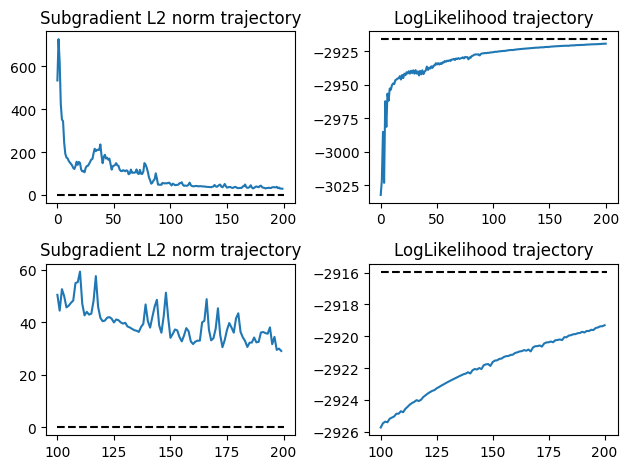

In [25]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [26]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector))))

-1.2 [-1.19627604]
-0.1 [-0.09191172]
-12 -12.28175051088652
A A 1.0 1.0059452319043487
A C -0.3 -0.28336624112971637
A T -1.0 -0.8981205584295213
A G -0.8 -0.7079564707987259
C A -0.6 -0.6006473947148397
C C 1.2 1.2139915688565472
C T -0.3 -0.2756604376484806
C G -1.0 -0.8245532603784475
T A -1.2 -1.087665384920032
T C -0.4 -0.4032411682743141
T T 1.0 0.994355688545122
T G -0.8 -0.7373319017379536
G A -0.4 -0.38899071929061557
G C -1.4 -1.0338679275238987
G T -0.9 -0.8471804920929409
G G 1.3 1.3087618017027118
[[1.         0.99594622]
 [0.99594622 1.        ]]
0.06584613018483171


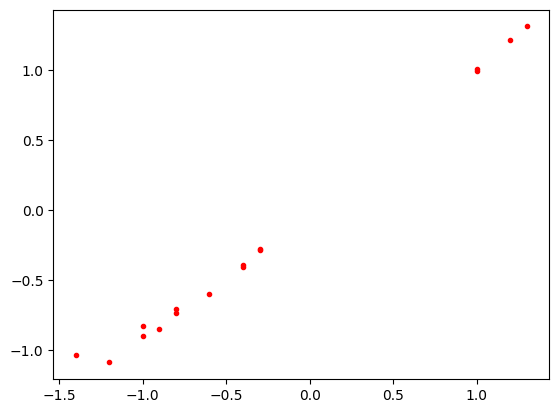

In [27]:
plt.figure()
plt.plot(true_subs_vector, param_subs_vector, 'r.')

In [28]:
from src.optimization import get_initial_estimate

In [29]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

{'alpha': -12.510359651242187,
 'substitution_matrix': Array([[ 1.035747  , -0.28576212, -1.00725787, -0.76980938],
        [-0.62016007,  1.24445203, -0.27855495, -0.92460282],
        [-1.23395366, -0.41371352,  1.02576908, -0.76105004],
        [-0.40423938, -1.36785736, -0.93451928,  1.34210605]],
          alphabet='ACTG'),
 'open_gap_score': -1.2412442385557685,
 'extend_gap_score': -0.0943680233961867}

In [30]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [34]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [35]:
estim_substitution

Array([[ 1.00594523, -0.28336624, -0.89812056, -0.70795647],
       [-0.60064739,  1.21399157, -0.27566044, -0.82455326],
       [-1.08766538, -0.40324117,  0.99435569, -0.7373319 ],
       [-0.38899072, -1.03386793, -0.84718049,  1.3087618 ]],
         alphabet='ACTG')

# Proteins

### Simulated alignments

In [339]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [351]:
coupling = 2**blosum62/(len(blosum62.alphabet)**2)
coupling /= np.sum(coupling)

In [355]:
aa_pairs = [(char1, char2) for char1 in blosum62.alphabet for char2 in blosum62.alphabet]
prob_vect = [coupling[aapair] for aapair in aa_pairs]

In [363]:
for aa, prob in zip(aa_pairs, prob_vect):
    print(aa, prob)

('A', 'A') 0.003933257536182897
('A', 'R') 0.00012291429800571552
('A', 'N') 6.145714900285776e-05
('A', 'D') 6.145714900285776e-05
('A', 'C') 0.00024582859601143104
('A', 'Q') 0.00012291429800571552
('A', 'E') 0.00012291429800571552
('A', 'G') 0.00024582859601143104
('A', 'H') 6.145714900285776e-05
('A', 'I') 0.00012291429800571552
('A', 'L') 0.00012291429800571552
('A', 'K') 0.00012291429800571552
('A', 'M') 0.00012291429800571552
('A', 'F') 6.145714900285776e-05
('A', 'P') 0.00012291429800571552
('A', 'S') 0.0004916571920228621
('A', 'T') 0.00024582859601143104
('A', 'W') 3.072857450142888e-05
('A', 'Y') 6.145714900285776e-05
('A', 'V') 0.00024582859601143104
('A', 'B') 6.145714900285776e-05
('A', 'Z') 0.00012291429800571552
('A', 'X') 0.00024582859601143104
('A', '*') 1.536428725071444e-05
('R', 'A') 0.00012291429800571552
('R', 'R') 0.007866515072365793
('R', 'N') 0.00024582859601143104
('R', 'D') 6.145714900285776e-05
('R', 'C') 3.072857450142888e-05
('R', 'Q') 0.0004916571920228

In [353]:
SETSIZE = 5000

In [359]:
Alist = []
Blist = []
for _ in range(SETSIZE):
    pairs = rd.choice(len(aa_pairs), p=prob_vect, replace=True, size=250)
    pairs = [aa_pairs[i] for i in pairs]
    aseq = ''.join(x[0] for x in pairs)
    bseq = ''.join(x[1] for x in pairs)
    Alist.append(aseq)
    Blist.append(bseq)

In [361]:
Blist

['CLWHWMHDWWHWWWWCHCWCCHYWCKFWHWWWYNHCWWWIWWWWCWWWWWCYDCCWWWWHCSTGWCWQYRYWWWWEHFWCWWPWBHCCILNWMPWCWYWEIHHWNQCWCPYWWWGWCWWNWWWWYWWCWWPCWNQXIZNFCPWCWWWWCWRCFYWCWWGWWCCWWQWNWWCCWQBEYWEWWMWWWCWEWWWYWWWWDVWYCVZZCWPCWWCWWEPWWWGWZMDWHFWWQWPCWCHWWWCWWWCWWWCQWW',
 'WWWDWCZYWWRBHWHHCWKWWWHWWWWWCYWTWHEWWNWVWGWCWHWWYFWWLWWGWHCQBCNFWYWWHTWWPDWWDWHCWCWWSWWWHSBWWWPWWNBZWYHWWWWQHYWTZWWWCRFWWWPWWWCWWHWWWWYHWMGCCCCQHPWWWYLYWWWWWWPWWZWCQWCWGQWHWHYWKWEWPWWPWCCCCWWWWWWYRWCWEWCHYWWWZWWCWWPCWWWWWCWCCWYGWWWWWWCWWWWIWWHWCWFZPH',
 'NWHWWCWNWWWWLWWWWHWWWHWWWWCWWWWCQTWWNCWWVWWDYWFCWCDWCCGHCRWWWCWWQHWCDDWYWDWRAWDWWWWWCCGPLPLWWWWNWZKWWTTWWGWCCYWCWCEWWNKWBCHWYYWWWBWWZWWWWWWWWWWWWAPWCCNYWHLHWNWCWWEYNWYCWCWWWHHWWWKWWWDWDTWWWWFCWHAWWWPCWHWBHWEVWHVLCCHCWWWWWPCYKEHWWGWWDMWWDWWCWWYWHWWMPF',
 'WWWMWWHCWCWHFWCFHWCPWYCWWHWKWWWWWWWYCAWWRWHHWWBWHWWFFWHWWWPWWWWWPWVDWWQWNHWNQFNWQWWBHWCWPWXWWHWCCCHWEYDHCWYCWCWNWHWFWCWZWWWSPWWWDWWGWWYWWWWHHGHWWWWWWHWPCWCHCAWWWWTWCWWHWWAKWPWWHNPBVWCWHWWHWWAKNWWWWHWWCWPZWKBPPTWWWWWFDHWWIMCSWPZWHWWWE

### Symmetric matrix on protein alignments:

In [112]:
positive_id_tuples = []
close_negative_id_tuples = []
with open('./Proteomes/human_to_chicken_upto1000aa.blast') as h:
    for l in h:
        l = l.split('\t')
        evalue = float(l[-2])
        if evalue == 0:
            positive_id_tuples.append([l[0], l[1]])
        elif evalue > 0.0001:
            close_negative_id_tuples.append([l[0], l[1]])

In [113]:
human_proteome = list(SeqIO.parse('Proteomes/GCF_000001405.40/up_to_1000.faa', 'fasta'))
chick_proteome = list(SeqIO.parse('Proteomes/GCF_016699485.2/up_to_1000.faa', 'fasta'))

In [121]:
alphabet = 'ACDEFGHIKLMNPQRSTVWY'

In [122]:
human_proteome = [seq for seq in human_proteome if set(str(seq.seq)).issubset(set(alphabet))]
chick_proteome = [seq for seq in chick_proteome if set(str(seq.seq)).issubset(set(alphabet))]

In [124]:
human_prot_ids = [seq.id for seq in human_proteome]
chick_prot_ids = [seq.id for seq in chick_proteome]

In [130]:
human_prot_ids_set = set(human_prot_ids)
chick_prot_ids_set = set(chick_prot_ids)

In [131]:
positive_id_tuples = [t for t in positive_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]
# close_negative_id_tuples = [t for t in close_negative_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]

In [286]:
SETSIZE = 5000

In [287]:
# pos_set = rd.choice(len(positive_id_tuples), SETSIZE//2, replace=False)
# neg_set = rd.choice(len(close_negative_id_tuples), SETSIZE//2, replace=False)
# prot_dset = [positive_id_tuples[i] for i in pos_set] + [close_negative_id_tuples[i] for i in neg_set]
pos_set = rd.choice(len(positive_id_tuples), SETSIZE, replace=False)
prot_dset = [positive_id_tuples[i] for i in pos_set]

In [288]:
human_list = [human_proteome[human_prot_ids.index(hpid)] for hpid, cpid in prot_dset]
chick_list = [chick_proteome[chick_prot_ids.index(cpid)] for hpid, cpid in prot_dset]

In [289]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [290]:
blosum62 /= np.sqrt(np.sum(blosum62**2))

In [293]:
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix=blosum62
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.1

Example scores of alignments to visualize gap open and extend penalties for global alignment:

In [294]:
test_aln = aligner.align('ATA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1, test_aln.score)
test_aln = aligner.align('ATTA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1 - 0.1, test_aln.score)

target            0 ATA 3
                  0 |-| 3
query             0 A-A 2

-0.866998755185649 -0.8669987551856488
target            0 ATTA 4
                  0 |--| 4
query             0 A--A 2

-0.9669987551856489 -0.9669987551856489


In [295]:
scores = np.array([aligner.score(a, b) for a, b in zip(human_list, chick_list)])

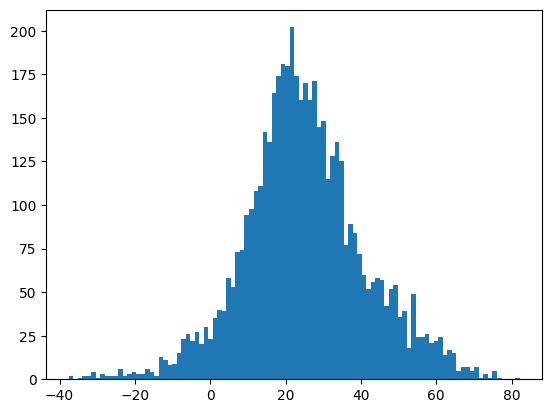

In [296]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [297]:
print(next(aligner.align(human_list[0], chick_list[0])))

XP_047305         0 MWRECDWGLGAVKSDLACVPSAKRLLCRMSNKDRHIDSSCSSFIKTEPSSPASLTDSVNH
                  0 ----------------------------||.|||||||||||.||||||||||||||.||
NP_001383         0 ----------------------------MSSKDRHIDSSCSSYIKTEPSSPASLTDSINH

XP_047305        60 HSPGGSSDASGSYSSTMNGHQNGLDSPPLYPSAPILGGSGPVRKLYDDCSSTIVEDPQTK
                 60 |||||||||||||||||||||||||||||||||..|||.|||||.||||||||.||.|||
NP_001383        32 HSPGGSSDASGSYSSTMNGHQNGLDSPPLYPSATGLGGNGPVRKRYDDCSSTIAEDSQTK

XP_047305       120 CEYMLNSMPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKR
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
NP_001383        92 CEYMLNSMPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKR

XP_047305       180 RRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRIDAENSPYLNPQLVQPAKKPLL
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||.-
NP_001383       152 RRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRIDAENSPYLNPQLVQPAKKPY-

XP_047305       240 WSDP

In [299]:
logit_scores = logit_partial_scores(scores, -20)

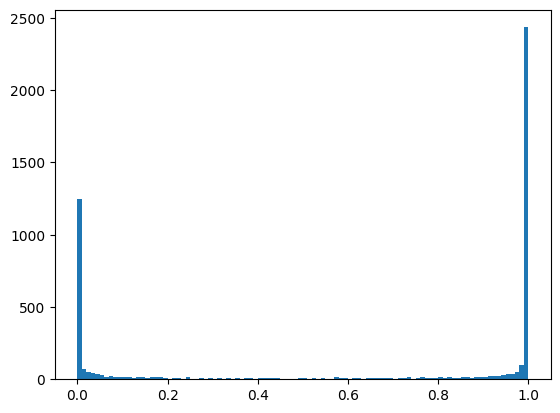

In [300]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

Expectation check:

In [301]:
logL_distribution = []
for _ in range(5000):
    labels = rd.rand(len(human_list))
    labels = labels <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    logL_distribution.append(true_logL)

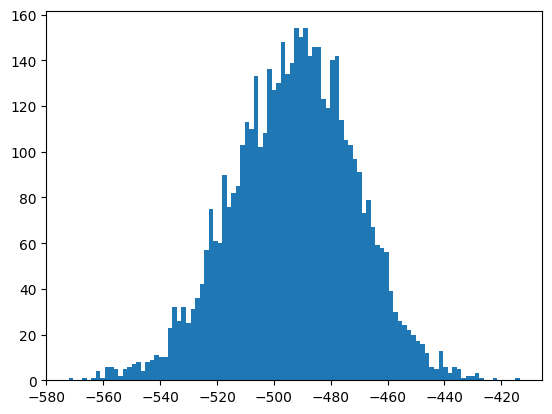

In [302]:
plt.figure()
plt.hist(logL_distribution, bins=100)
plt.show()

In [303]:
EL = 0 
VL = 0
for ls in logit_scores:
    if 1e-24 < ls < 1-1e-24:
        EL += ls*np.log(ls) + (1-ls)*np.log(1-ls)
        VL += ls*(1-ls)*(np.log(ls)**2 + np.log(1-ls)**2) # Incorrect
SDL = np.sqrt(VL)

In [304]:
print('Expected LogL:', EL)
print('Average LogL:', np.mean(logL_distribution))
print('STD LogL:', SDL)
print('Sample STD:', np.std(logL_distribution))

Expected LogL: -492.961331556755
Average LogL: -492.83136372138114
STD LogL: 23.83982117588265
Sample STD: 21.590079372381034


Fitting:

In [321]:
labels = rd.rand(len(human_list))
labels = labels <= logit_scores

In [322]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [323]:
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -19494.686981856918
True LogL: -473.3818560942222


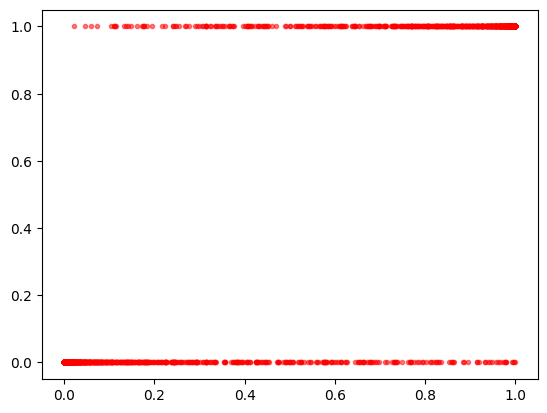

In [324]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.5)

In [325]:
const_step = create_constant_step(0.00005)
powerstep = create_powerstep(0.000005, power=0.5, burnin=0) # step 0.00005 good for SETSIZE==1000
# powerstep = create_powerstep(0.0000001, power=-0.5, burnin=0)

In [326]:
NITER = 50

In [327]:
set('WEIMFASVCGKLTHDPRNQY') == set(alphabet) 

True

In [328]:
params = estimalign(human_list, chick_list, labels, 
                    stepfunction=powerstep,
                    aligner_mode='global',
                    substitution_mode='general',
                    gap_mode='affine',
                    baseline_aligner=aligner,
                    stochastic_factor=0.0001,
                    verbose=True, max_iter=NITER,
                    num_threads = 16)

Alphabet:
WEIMFASVCGKLTHDPRNQY
Initial parameters:
{'alpha': -35.101053302810854, 'substitution_matrix': Array([[ 3.48825056e-01,  5.99924929e-01,  4.17629018e-01,
        -3.73187553e-01,  2.80712973e-01, -1.92579665e-01,
         3.63649868e-01,  9.24646410e-02, -1.82697874e-01,
        -6.20571638e-01, -1.54715365e-02,  6.81000778e-01,
         1.58561460e-01, -4.91615555e-01,  1.05286898e-03,
        -2.14071773e-01, -1.38160217e-01, -1.69362192e-01,
         6.91424458e-01, -3.87961231e-01],
       [-4.95390953e-01,  1.48953091e-01, -6.88399086e-02,
         6.09065215e-01, -1.43467004e+00,  9.93699223e-02,
        -4.62401007e-02,  1.67419103e-01,  3.88079948e-01,
        -3.55739288e-01,  8.98176490e-02, -1.61843964e-01,
         5.73399833e-01, -2.31427963e-01,  2.02452881e-01,
        -4.76874094e-01,  1.77812210e-01, -3.45593184e-01,
         1.37161711e-01, -8.47186878e-01],
       [-6.42274608e-01, -3.10288428e-01,  8.40838074e-02,
        -1.61377649e-01, -5.64385627e-02, 

New subgradient:
{'Substitutions': Array([[  -47.7684489 ,  -220.26929544,  -105.50773594,    -7.01214256,
          -76.02983061,   -48.78249437,  -235.7573384 ,   -58.36578767,
          -23.66710737,   -20.75172482,   -64.13234295,  -355.91045585,
          -59.92653873,   -15.91732101,   -50.2415697 ,   -51.44503821,
          -63.43606471,   -33.60601043,  -137.97632614,   -25.39556852],
       [  -37.92136608,   300.20734013,  -419.0900276 ,  -350.36591961,
          -17.5241978 ,  -816.83883446,  -969.46281793,  -683.13555567,
         -360.16776974,  -393.19380616,  -988.96160533,  -683.01656583,
        -1334.22180537,  -198.47670639, -1120.94709794,  -266.75772339,
         -815.70393392,  -212.55428739,  -812.58635283,   -51.66071017],
       [   -6.6143843 ,  -256.48534313,  2052.87193971,   -82.52483079,
         -177.22355121,  -297.61798522,  -906.77248257,  -559.26583523,
         -261.07693898,  -234.33267272,  -762.34928305,  -765.73498853,
         -210.48352036,   -

Current alpha: -44.71348152155573
Current logL: -3505.7510822265153
Updated alpha: -43.1292506112052
Updated logL: -3388.4070515014323
New subgradient:
{'Substitutions': Array([[  -53.20560113,  -152.01484423,   -85.5844822 ,    -5.66701974,
          -68.01529743,   -35.19542024,  -186.99831358,   -43.75809394,
          -21.2496579 ,   -13.12832326,   -52.31956948,  -286.1127478 ,
          -47.50177923,   -11.66927393,   -38.17740963,   -48.01508159,
          -55.94891913,   -37.11826284,  -108.94376676,   -22.45866758],
       [  -31.59055768,   736.83634036,  -335.64745037,  -272.08460854,
          -14.95851692,  -596.00656909,  -795.15038398,  -484.64846039,
         -279.33113581,  -301.39801595,  -775.00494578,  -536.46228434,
        -1010.90647842,  -164.76315726,  -952.71081789,  -201.71481495,
         -614.4779133 ,  -212.35452842,  -637.71931093,   -48.61404158],
       [  -14.27648429,  -183.97067938,  1608.88968224,   -94.3217098 ,
         -151.40050126,  -236.260194

Current alpha: -43.1292506112052
Current logL: -3070.471051749851
Updated alpha: -44.014290906156965
Updated logL: -3033.946813148275
New subgradient:
{'Substitutions': Array([[  -90.36934652,  -147.63233416,   -75.56851525,    -5.69173944,
          -62.16621248,   -35.72769956,  -170.68856639,   -37.3721081 ,
          -21.43247823,   -11.79414617,   -42.30508789,  -265.29976508,
          -46.87511073,   -12.01609914,   -31.00447709,   -46.93150341,
          -56.60839937,   -34.73134572,   -98.96505641,   -20.43495507],
       [  -31.13127624,   471.14531503,  -317.42538295,  -261.43425368,
          -11.69819919,  -563.09332249,  -745.90558167,  -450.37239384,
         -256.96389771,  -275.33759425,  -718.45987   ,  -485.29956995,
         -942.5116009 ,  -153.3570828 ,  -896.05923611,  -197.69346339,
         -579.68834565,  -197.87764187,  -597.27365416,   -45.77458957],
       [  -14.13314041,  -168.17733147,  1383.1626053 ,   -89.25144306,
         -135.57356892,  -214.5518444

Current alpha: -44.014290906156965
Current logL: -2805.9280024074606
Updated alpha: -44.47376231668779
Updated logL: -2796.1207759285717
New subgradient:
{'Substitutions': Array([[ -101.75583512,  -139.01518046,   -69.76756237,    -5.1469448 ,
          -58.72116187,   -32.81877711,  -155.85020182,   -34.19291107,
          -20.82554237,   -11.29088776,   -38.77806948,  -249.18328973,
          -43.68358786,   -12.4438557 ,   -29.26041433,   -44.66453717,
          -56.7908306 ,   -33.13982218,   -94.91712889,   -19.58600908],
       [  -30.2891651 ,   339.21794619,  -304.27578326,  -245.46480888,
          -10.93863475,  -529.5964806 ,  -707.45572374,  -432.32703362,
         -243.17843594,  -260.51530445,  -686.60446559,  -461.88619459,
         -902.88738297,  -143.68765172,  -850.62491292,  -184.2026764 ,
         -550.19137291,  -187.25120862,  -563.37485751,   -41.49460719],
       [  -13.4665538 ,  -161.7908409 ,  1250.22637714,   -82.939515  ,
         -125.60492622,  -202.7828

...

Current alpha: -44.70738675453603
Current logL: -1248.8386690306484
Updated alpha: -44.67863961868739
Updated logL: -1248.8033507463783
New subgradient:
{'Substitutions': Array([[-9.28262007e+01, -6.71117100e+01, -3.77522565e+01,
        -1.89249106e+00, -1.98037139e+01, -1.30017038e+01,
        -5.66032547e+01, -1.25722286e+01, -5.05421966e+00,
        -1.04468174e+01, -1.71512677e+01, -1.02074141e+02,
        -2.09934156e+01, -4.13199702e+00, -1.35701939e+01,
        -1.67748324e+01, -3.12441001e+01, -1.48056637e+01,
        -4.07637235e+01, -4.95583212e+00],
       [-1.61182981e+01, -1.53148963e+02, -1.55473926e+02,
        -9.35599176e+01, -2.11896849e+00, -2.12939077e+02,
        -3.07878615e+02, -1.94625065e+02, -1.01601023e+02,
        -1.23856784e+02, -3.14786055e+02, -1.91308576e+02,
        -4.37987098e+02, -6.14777531e+01, -3.47580096e+02,
        -7.11642478e+01, -2.72259566e+02, -9.45376463e+01,
        -2.19417445e+02, -2.23532690e+01],
       [-5.78865658e+00, -8.2336547

Current alpha: -44.67863961868739
Current logL: -1240.6699287786155
Updated alpha: -44.650790559668316
Updated logL: -1240.6368596874354
New subgradient:
{'Substitutions': Array([[-9.17191489e+01, -6.65112883e+01, -3.74056039e+01,
        -1.85556807e+00, -1.95961925e+01, -1.27689769e+01,
        -5.59055926e+01, -1.24825572e+01, -4.95328244e+00,
        -1.03350237e+01, -1.70041076e+01, -1.01075324e+02,
        -2.08181533e+01, -4.09183090e+00, -1.34993366e+01,
        -1.66077590e+01, -3.09272548e+01, -1.46410747e+01,
        -4.03941803e+01, -4.83765353e+00],
       [-1.59641616e+01, -1.53001329e+02, -1.54524785e+02,
        -9.28407550e+01, -2.06854522e+00, -2.10536056e+02,
        -3.04657583e+02, -1.92814297e+02, -1.00674088e+02,
        -1.22194372e+02, -3.12213452e+02, -1.89561336e+02,
        -4.34476256e+02, -6.08366456e+01, -3.43938602e+02,
        -7.03388557e+01, -2.70042506e+02, -9.36346033e+01,
        -2.17222540e+02, -2.22292972e+01],
       [-5.77797991e+00, -8.169781

Current alpha: -44.650790559668316
Current logL: -1232.761664824608
Updated alpha: -44.623428227297936
Updated logL: -1232.7298028139173
New subgradient:
{'Substitutions': Array([[-9.17214233e+01, -6.54593965e+01, -3.75439319e+01,
        -1.81962815e+00, -1.93944346e+01, -1.20747778e+01,
        -5.56950168e+01, -1.23944147e+01, -4.85362963e+00,
        -1.02251572e+01, -1.68602088e+01, -1.00102332e+02,
        -2.01770103e+01, -4.05147338e+00, -1.34302849e+01,
        -1.64465198e+01, -3.06133138e+01, -1.44800092e+01,
        -4.00337892e+01, -4.72289205e+00],
       [-1.58130836e+01, -1.57236034e+02, -1.52047903e+02,
        -9.16784853e+01, -2.02073652e+00, -2.07550749e+02,
        -3.00482981e+02, -1.91064540e+02, -9.99716516e+01,
        -1.21816838e+02, -3.08345727e+02, -1.87409700e+02,
        -4.31115048e+02, -6.02516244e+01, -3.41715328e+02,
        -6.94666083e+01, -2.67121476e+02, -9.27794407e+01,
        -2.13920928e+02, -2.25786845e+01],
       [-5.76721764e+00, -8.198197

Current alpha: -44.623428227297936
Current logL: -1225.1094938389372
Updated alpha: -44.595409327438176
Updated logL: -1225.0761465244157
New subgradient:
{'Substitutions': Array([[-9.07050819e+01, -6.49024151e+01, -3.72033345e+01,
        -1.78447809e+00, -1.91993974e+01, -1.18701359e+01,
        -5.50223033e+01, -1.23314447e+01, -4.75612015e+00,
        -1.01174785e+01, -1.73574284e+01, -9.97930058e+01,
        -1.80218853e+01, -4.01117255e+00, -1.33628155e+01,
        -1.62915513e+01, -3.03046274e+01, -1.43228407e+01,
        -3.96824070e+01, -4.61218804e+00],
       [-1.56649677e+01, -1.56145668e+02, -1.51819955e+02,
        -9.16331445e+01, -1.93631462e+00, -2.04733162e+02,
        -2.97515354e+02, -1.89346123e+02, -9.91060194e+01,
        -1.20211938e+02, -3.05902885e+02, -1.85759018e+02,
        -4.28462257e+02, -5.96543002e+01, -3.38253651e+02,
        -6.86480105e+01, -2.65072195e+02, -9.12827735e+01,
        -2.12496691e+02, -2.24492537e+01],
       [-3.75650595e+00, -8.13461

Current alpha: -44.595409327438176
Current logL: -1217.6696828767713
Updated alpha: -44.567879331308276
Updated logL: -1217.6375468432702
New subgradient:
{'Substitutions': Array([[-8.97089157e+01, -6.43527681e+01, -3.68690488e+01,
        -1.75014011e+00, -1.90093587e+01, -1.16705392e+01,
        -5.43654859e+01, -1.22414177e+01, -4.66000393e+00,
        -1.00115162e+01, -1.72223346e+01, -9.88493765e+01,
        -1.78679411e+01, -3.97078101e+00, -1.32968092e+01,
        -1.61417967e+01, -2.99990266e+01, -1.41689422e+01,
        -3.93391892e+01, -4.50455733e+00],
       [-1.55194059e+01, -1.55653319e+02, -1.50977266e+02,
        -9.08965699e+01, -1.87506771e+00, -2.01597602e+02,
        -2.95514903e+02, -1.85762778e+02, -9.82574529e+01,
        -1.18579547e+02, -3.03461379e+02, -1.84197122e+02,
        -4.25254286e+02, -5.90704370e+01, -3.35863853e+02,
        -6.78465204e+01, -2.62099329e+02, -9.04475938e+01,
        -2.12510310e+02, -2.23222834e+01],
       [-3.74559491e+00, -8.07211

In [329]:
print(params['final_loglik'])

-1210.446812154434


In [330]:
print(max(params['loglik_trajectory']))

-1210.446812154434


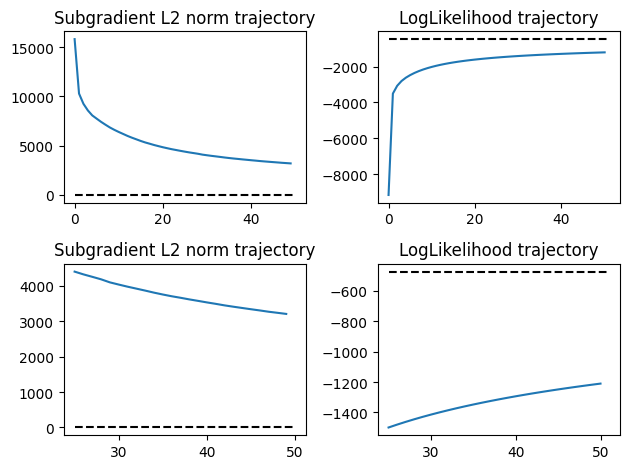

In [331]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [332]:
print(params['open_gap_score'], aligner.open_gap_score)
print(params['extend_gap_score'], aligner.extend_gap_score)

[-1.90709157] -1.0
[-0.20770575] -0.1


In [333]:
params['alpha']

-44.567879331308276

In [334]:
blosum_vs_mine = []
for char1 in params['substitution_matrix'].alphabet:
    for char2 in params['substitution_matrix'].alphabet:
        if char1 != 'N' and char2 != 'N':
            blosum_vs_mine.append([char1, char2,blosum62[char1, char2], params['substitution_matrix'][char1, char2]])

In [335]:
print('Blosum, Mine')
for i in rd.choice(len(blosum_vs_mine), 10, replace=False):
    print(blosum_vs_mine[i])

Blosum, Mine
['M', 'Y', -0.01662515560179388, -0.7314207883187804]
['G', 'S', 0.0, -0.1622084945113686]
['P', 'G', -0.03325031120358776, -0.0966635860368927]
['T', 'G', -0.03325031120358776, -0.318430782059466]
['A', 'Y', -0.03325031120358776, -0.2122895257976945]
['H', 'M', -0.03325031120358776, 0.2817241247930328]
['E', 'A', -0.01662515560179388, 0.07353925170021357]
['A', 'C', 0.0, 0.2965257647460072]
['M', 'S', -0.01662515560179388, 0.397984359654686]
['L', 'S', -0.03325031120358776, -0.06714113950960687]


In [336]:
np.corrcoef([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine])

array([[1.        , 0.14812141],
       [0.14812141, 1.        ]])

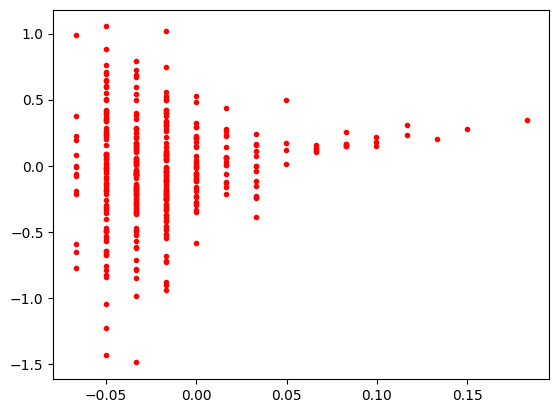

In [337]:
plt.figure()
plt.plot([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine], 'r.')

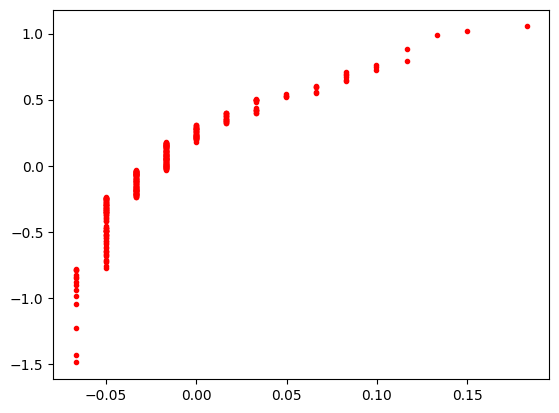

In [338]:
plt.figure()
plt.plot(sorted([x[2] for x in blosum_vs_mine]), sorted([x[3] for x in blosum_vs_mine]), 'r.')